# Supplementary figures — copied from `../Recursive_Introns.ipynb`

**This is a near-verbatim copy of the source notebook**, not a cleaned
reproduction. Only inert cells were removed: empty cells, cells that are
entirely commented out, and cells that only `print()` or display a table.
Every cell that computes or plots anything is untouched.

Panels produced here: `Percentage_GT_next_exon`(`_long_introns`), `RNAtype_BFS_*`, `tissue_BFS_*`

Two mechanical path edits were applied so the notebook runs from this directory
and cannot overwrite the published figures:

* `../code/...` → `../../code/...` (this notebook sits one level deeper)
* `../code/plots/` → `plots/` and `../code/revision_plots/` → `revision_plots/`

Cells unrelated to the supplementary panels were **kept**, so this notebook may
compute more than it needs to. That is the trade for not re-tracing it.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import gzip
import pickle
import sys
from bisect import insort
from statistics import mean, median, mode, multimode
from tqdm import tqdm
import pyfastx
from Bio.Seq import Seq
import os

In [2]:
tissues_49 = sorted(set([x.split('.')[0] for x in os.listdir(
    '/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/')]))

In [3]:
len(tissues_49)

49

In [15]:
tissue_bfs = {}
for tissue in tqdm(tissues_49):
    tissue_class = pd.read_csv(
        f'/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/{tissue}/leafcutter_junction_classifications.txt',
                         sep='\t')

    tissue_class['junc_gene'] = tissue_class.Intron_coord + ':' + tissue_class.Strand + ':' + tissue_class.Gene_name
    tissue_class['junc'] = tissue_class.Intron_coord + ':' + tissue_class.Strand

    tissue_bfs.update({tissue:tissue_class})


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:19<00:00,  2.52it/s]


In [16]:
sorted(tissue_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(tissue_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in tissue_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = (~rin_class_merged.loc[rin_class_merged.Coding_x == True].Coding_y).sum()
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

Adipose-Subcutaneous
Adipose-Visceral_Omentum
AdrenalGland
Artery-Aorta
Artery-Coronary
Artery-Tibial
Brain-Amygdala
Brain-Anteriorcingulatecortex_BA24
Brain-Caudate_basalganglia
Brain-CerebellarHemisphere
Brain-Cerebellum
Brain-Cortex
Brain-FrontalCortex_BA9
Brain-Hippocampus
Brain-Hypothalamus
Brain-Nucleusaccumbens_basalganglia
Brain-Putamen_basalganglia
Brain-Spinalcord_cervicalc-1
Brain-Substantianigra
Breast-MammaryTissue
Cells-Culturedfibroblasts
Cells-EBV-transformedlymphocytes
Colon-Sigmoid
Colon-Transverse
Esophagus-GastroesophagealJunction
Esophagus-Mucosa
Esophagus-Muscularis
Heart-AtrialAppendage
Heart-LeftVentricle
Kidney-Cortex
Liver
Lung
MinorSalivaryGland
Muscle-Skeletal
Nerve-Tibial
Ovary
Pancreas
Pituitary
Prostate
Skin-NotSunExposed_Suprapubic
Skin-SunExposed_Lowerleg
SmallIntestine-TerminalIleum
Spleen
Stomach
Testis
Thyroid
Uterus
Vagina
WholeBlood


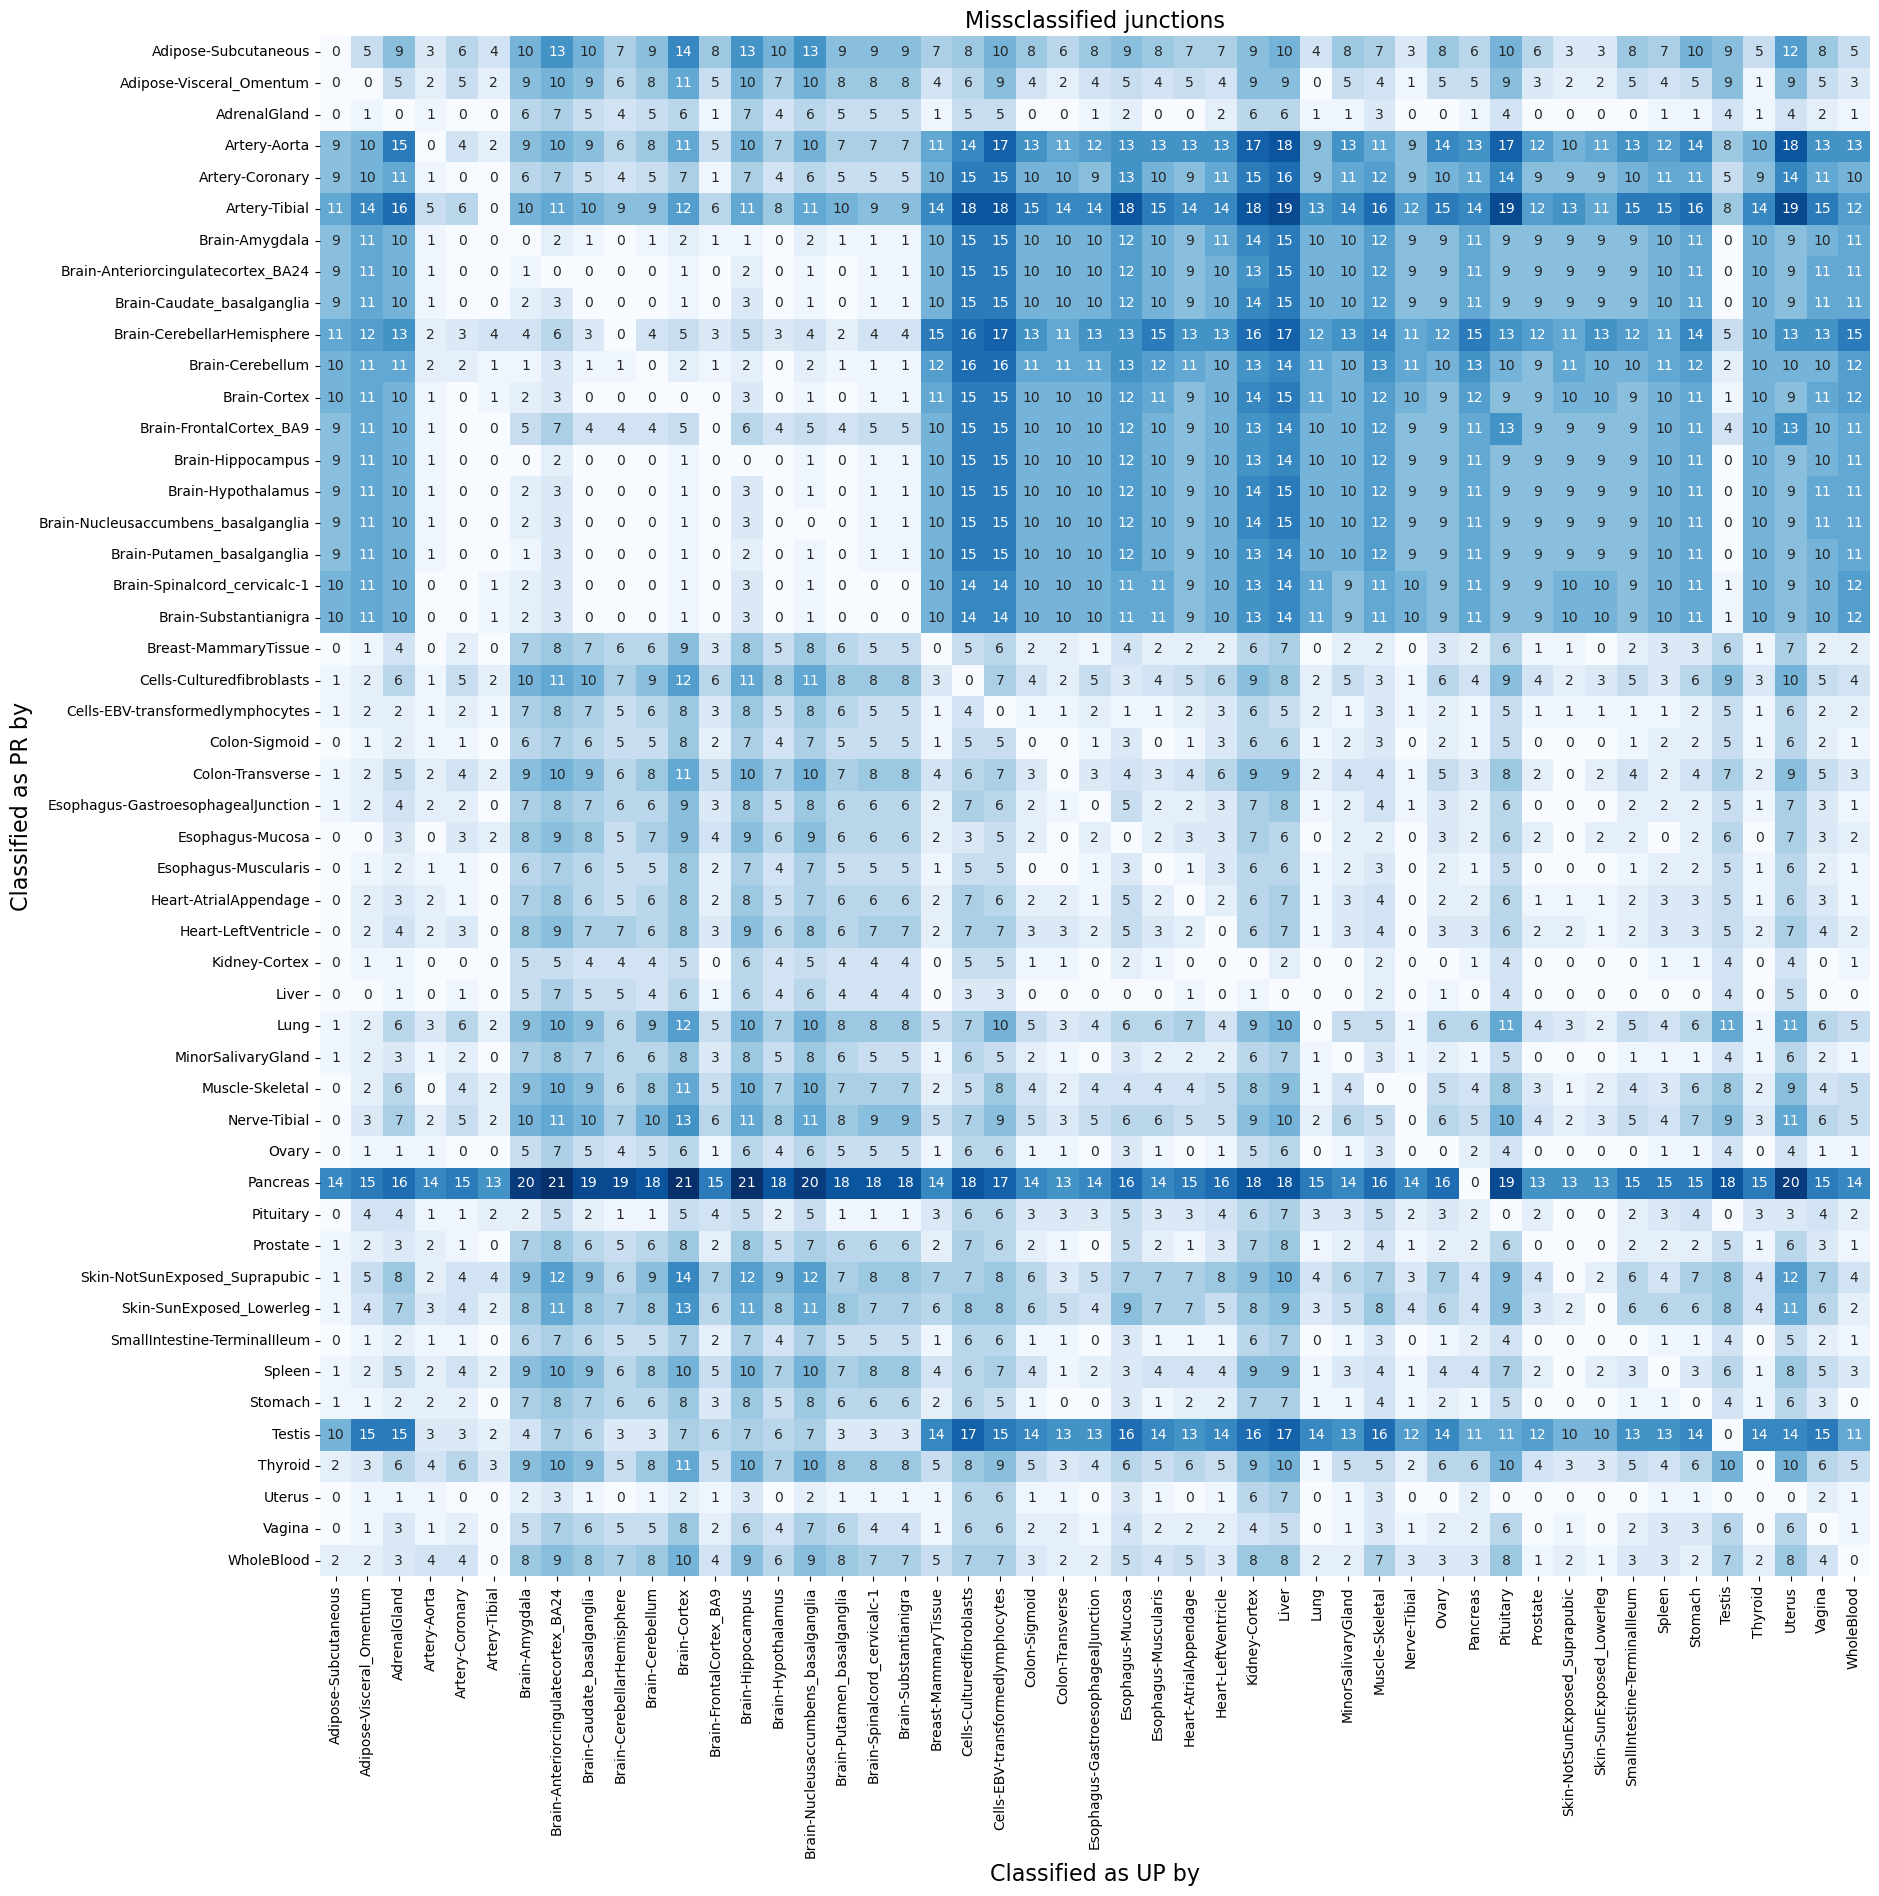

In [17]:
fig, ax = plt.subplots(figsize=(20,20))
g = sns.heatmap(pd.DataFrame(rin_df, columns = sorted(tissue_bfs.keys()), index = sorted(tissue_bfs.keys())),
               annot = True, cbar=False, ax = ax, cmap='Blues')

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by', size=16)
g.axes.set_xlabel('Classified as UP by', size=16)
g.axes.set_title('Missclassified junctions', size=16)

plt.savefig('revision_plots/tissue_BFS_misclassification.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/tissue_BFS_misclassification.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/tissue_BFS_misclassification.svg', dpi=300, bbox_inches='tight')    

In [28]:
sorted(tissue_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(tissue_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in tissue_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = 100*(~rin_class_merged.loc[rin_class_merged.Coding_x == True].Coding_y).mean()
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

Adipose-Subcutaneous
Adipose-Visceral_Omentum
AdrenalGland
Artery-Aorta
Artery-Coronary
Artery-Tibial
Brain-Amygdala
Brain-Anteriorcingulatecortex_BA24
Brain-Caudate_basalganglia
Brain-CerebellarHemisphere
Brain-Cerebellum
Brain-Cortex
Brain-FrontalCortex_BA9
Brain-Hippocampus
Brain-Hypothalamus
Brain-Nucleusaccumbens_basalganglia
Brain-Putamen_basalganglia
Brain-Spinalcord_cervicalc-1
Brain-Substantianigra
Breast-MammaryTissue
Cells-Culturedfibroblasts
Cells-EBV-transformedlymphocytes
Colon-Sigmoid
Colon-Transverse
Esophagus-GastroesophagealJunction
Esophagus-Mucosa
Esophagus-Muscularis
Heart-AtrialAppendage
Heart-LeftVentricle
Kidney-Cortex
Liver
Lung
MinorSalivaryGland
Muscle-Skeletal
Nerve-Tibial
Ovary
Pancreas
Pituitary
Prostate
Skin-NotSunExposed_Suprapubic
Skin-SunExposed_Lowerleg
SmallIntestine-TerminalIleum
Spleen
Stomach
Testis
Thyroid
Uterus
Vagina
WholeBlood


In [49]:
tissue_bfs_df = pd.DataFrame(rin_df, columns = sorted(tissue_bfs.keys()), index = sorted(tissue_bfs.keys()))

In [51]:
tissue_bfs_df.to_csv('../../code/analysis_files/tissue_bfs_differences.pct.tab.gz', sep='\t', index=True, header=True)

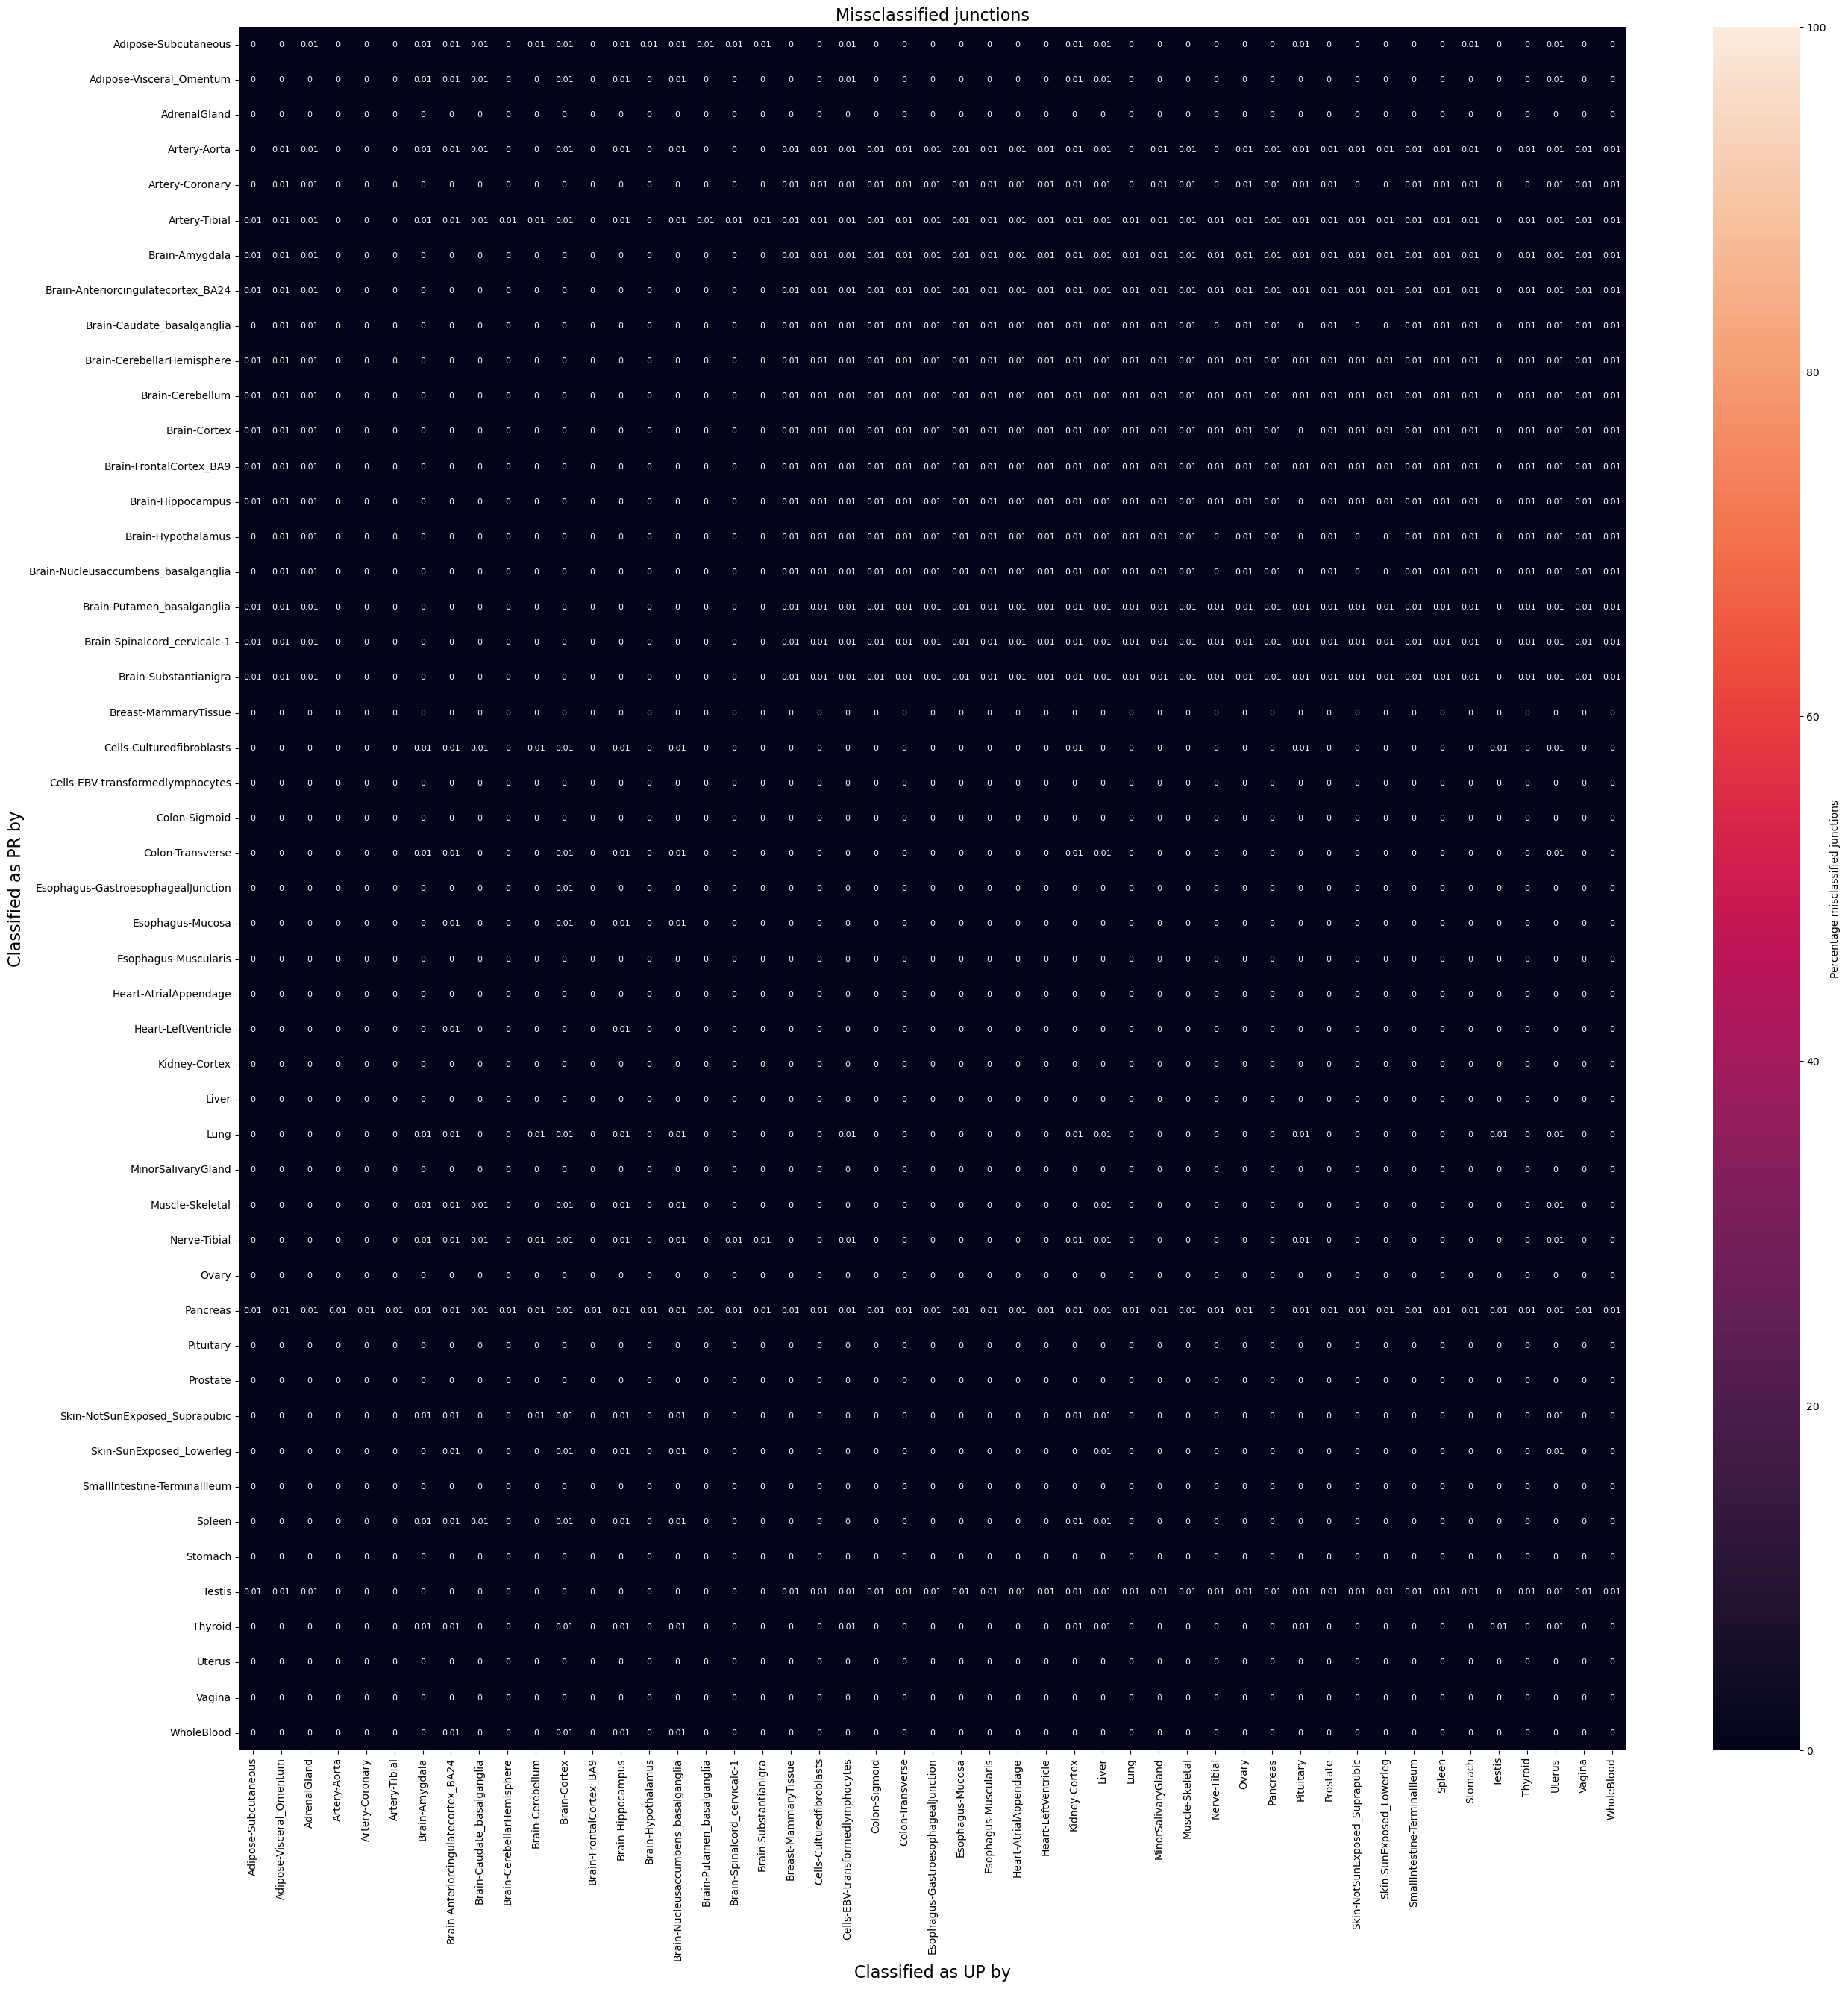

In [54]:
fig, ax = plt.subplots(figsize=(30,30))
g = sns.heatmap(tissue_bfs_df.round(2),
               annot = True, ax = ax, vmax=100, cbar_kws={'label': 'Percentage misclassified junctions'}, annot_kws={'size': 8})

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by', size=16)
g.axes.set_xlabel('Classified as UP by', size=16)
g.axes.set_title('Missclassified junctions', size=16)

plt.savefig('revision_plots/tissue_BFS_misclassification_pct.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/tissue_BFS_misclassification_pct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/tissue_BFS_misclassification_pct.svg', dpi=300, bbox_inches='tight')    

In [4]:
rna_bfs = {}
for RNAtype in tqdm(['nascent', 'steady_state']):
    RNA_class = pd.read_csv(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/LCLs/{RNAtype}/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')

    RNA_class['junc_gene'] = RNA_class.Intron_coord + ':' + RNA_class.Strand + ':' + RNA_class.Gene_name
    RNA_class['junc'] = RNA_class.Intron_coord + ':' + RNA_class.Strand

    rna_bfs.update({RNAtype:RNA_class})


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.11s/it]


In [60]:
sorted(rna_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(rna_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in rna_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = np.sum(rin_class_merged.loc[rin_class_merged.junc_x.isin(rin_class_merged.loc[rin_class_merged.Coding_x].junc_x.unique())].groupby('junc_x').Coding_y.sum() == 0)
        # pct_PR = (~rin_class_merged.loc[rin_class_merged.Coding_x == True].Coding_y).sum()
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

nascent
steady_state


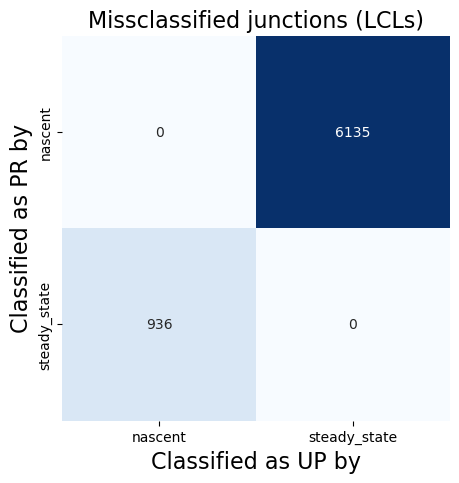

In [61]:
fig, ax = plt.subplots(figsize=(5,5))


g = sns.heatmap(pd.DataFrame(rin_df, columns = sorted(rna_bfs.keys()), index = sorted(rna_bfs.keys())),
               annot = True, fmt = 'd', cbar=False, ax = ax, cmap='Blues')

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by', size=16)
g.axes.set_xlabel('Classified as UP by', size=16)
g.axes.set_title('Missclassified junctions (LCLs)', size=16)

plt.savefig('revision_plots/RNAtype_BFS_misclassification.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_misclassification.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_misclassification.svg', dpi=300, bbox_inches='tight')    

In [63]:
sorted(rna_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(rna_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in rna_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = 100*(1-np.mean(rin_class_merged.loc[rin_class_merged.junc_x.isin(rin_class_merged.loc[rin_class_merged.Coding_x].junc_x.unique())].groupby('junc_x').Coding_y.sum() > 0))
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

nascent
steady_state


In [19]:
len(rna_bfs['steady_state'].junc.unique())

406215

In [18]:
len(rna_bfs['nascent'].junc.unique())

805061

In [20]:
len(pd.Index(rna_bfs['nascent'].junc.unique()).difference(pd.Index(rna_bfs['steady_state'].junc.unique())))

436449

In [ ]:
rin1.merge(rin2, on = 'junc_gene')

In [28]:
6286/(805061-436449)

368612

In [26]:
rin_class_merged = rna_bfs['nascent'].merge(rna_bfs['steady_state'], on = 'junc_gene')

In [36]:
len(rin_class_merged.loc[rin_class_merged.Coding_x].Coding_y)

200040

In [52]:
1-np.mean(rin_class_merged.loc[rin_class_merged.junc_x.isin(rin_class_merged.loc[rin_class_merged.Coding_x].junc_x.unique())].groupby('junc_x').Coding_y.sum() > 0)

np.float64(0.03102919829857831)

In [57]:
6135/197717

0.03102919829857827

In [59]:
len(rin_class_merged.loc[rin_class_merged.Coding_x].junc_x.unique())

197717

In [37]:
6286/200040

0.03142371525694861

In [65]:
pd.DataFrame(rin_df, columns = sorted(rna_bfs.keys()), index = sorted(rna_bfs.keys()))

,nascent,steady_state
nascent,0.000000,3.10292
steady_state,0.486188,0.00000


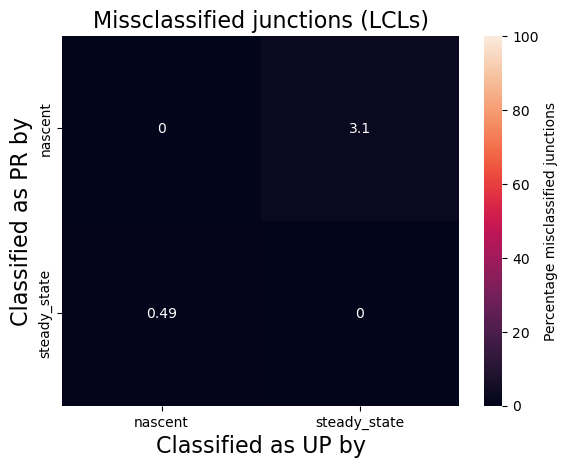

In [64]:
# fig, ax = plt.subplots(figsize=(5,5))


g = sns.heatmap(pd.DataFrame(rin_df, columns = sorted(rna_bfs.keys()), index = sorted(rna_bfs.keys())),
               annot = True,  cbar=True, vmax=100, cbar_kws={'label': 'Percentage misclassified junctions'}, )

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by', size=16)
g.axes.set_xlabel('Classified as UP by', size=16)
g.axes.set_title('Missclassified junctions (LCLs)', size=16)

plt.savefig('revision_plots/RNAtype_BFS_misclassification_pct.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_misclassification_pct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_misclassification_pct.svg', dpi=300, bbox_inches='tight')    

In [21]:

sorted(rna_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(rna_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in rna_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        missing_juncs = len(pd.Index(rin1.junc.unique()).difference(pd.Index(rin2.junc.unique())))

        rin_row.append(missing_juncs)
    rin_df.append(rin_row)

nascent
steady_state


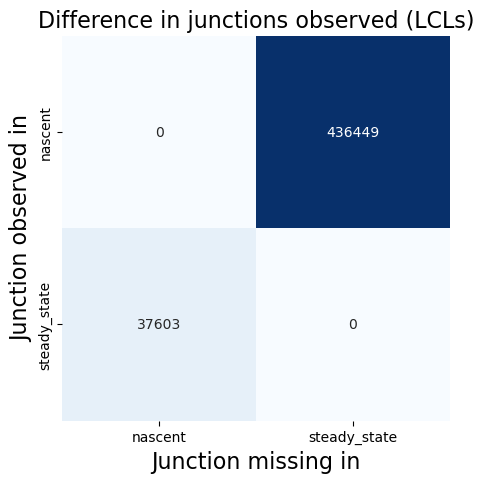

In [24]:
fig, ax = plt.subplots(figsize=(5,5))

g = sns.heatmap(pd.DataFrame(rin_df, columns = sorted(rna_bfs.keys()), index = sorted(rna_bfs.keys())),
               annot = True, fmt='d', cbar=False, cbar_kws={'label': 'Missing junctions'}, cmap='Blues')

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Junction observed in', size=16)
g.axes.set_xlabel('Junction missing in', size=16)
g.axes.set_title('Difference in junctions observed (LCLs)', size=16)


plt.savefig('revision_plots/RNAtype_BFS_missing_juncs.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_missing_juncs.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_missing_juncs.svg', dpi=300, bbox_inches='tight') 

In [84]:

sorted(rna_bfs.keys())

rin_df = []
for tissue, rin1 in sorted(rna_bfs.items()):
    print(tissue)
    rin_row = []
    for tissue, rin2 in rna_bfs.items():
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        missing_juncs = 100*len(pd.Index(rin1.junc.unique()).difference(pd.Index(rin2.junc.unique())))/len(pd.Index(rin1.junc.unique()))

        rin_row.append(missing_juncs)
    rin_df.append(rin_row)

nascent
steady_state


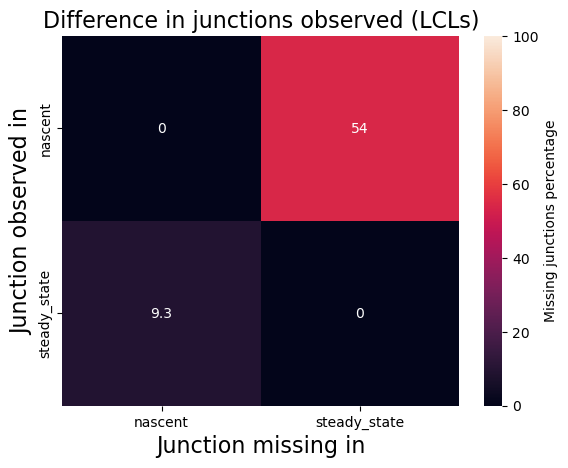

In [85]:
g = sns.heatmap(pd.DataFrame(rin_df, columns = sorted(rna_bfs.keys()), index = sorted(rna_bfs.keys())),
               annot = True, cbar=True, cbar_kws={'label': 'Missing junctions percentage'}, vmax=100)

# g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, figsize=(15, 15))
# g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
# g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Junction observed in', size=16)
g.axes.set_xlabel('Junction missing in', size=16)
g.axes.set_title('Difference in junctions observed (LCLs)', size=16)

plt.savefig('revision_plots/RNAtype_BFS_missing_juncs_pct.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_missing_juncs_pct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/RNAtype_BFS_missing_juncs_pct.svg', dpi=300, bbox_inches='tight')

In [136]:
def get_diplets(fa, chrom, start, end, strand):
    if strand == '+':
        D5 = str(Seq(fa.fetch(chrom, (start + 1, start + 2))))
        D3_Exon = str(Seq(fa.fetch('chr1', (end -1,end + 2))))
    else:
        D5 = str(Seq(fa.fetch(chrom, (end - 1, end))).reverse_complement())
        D3_Exon = str(Seq(fa.fetch('chr1', (start -1,start + 2))))
        
    D3 = D3_Exon[:2]
    Exon = D3_Exon[2:]

    return D5, D3, Exon

def get_diplets_full(fa, chrom, start, end, strand):
    if strand == '+':
        intron = str(Seq(fa.fetch(chrom, (start + 1, end + 2))))
        

    else:
        intron = str(Seq(fa.fetch(chrom, (start -1, end))).reverse_complement())

    D5 = intron[:2]
    D3_Exon = intron[-4:]
    D3 = D3_Exon[:2]
    Exon = D3_Exon[2:]
    return D5, D3, Exon

genome = '/project/yangili1/cdai/genome_index/hs38/GRCh38.primary_assembly.genome.fa'
fa = pyfastx.Fasta(genome)
    
diplet_5 = []
diplet_3 = []
diplet_next_exon = []
intron_len = []

for idx, row in tqdm(brain_class.iterrows()):
    chrom, coords = row.Intron_coord.split(':')
    start, end = coords.split('-')
    start = int(start)
    end = int(end)
    strand = row.Strand
    intron_len.append(end - start)

    try:
        D5, D3, Exon = get_diplets_full(fa, chrom, start, end, strand)
        diplet_5.append(D5)
        diplet_3.append(D3)
        diplet_next_exon.append(Exon)
        
    except:
        diplet_5.append("")
        diplet_3.append("")
        diplet_next_exon.append("")
        
    # diplet_5.append(D5)
    # diplet_3.append(D3)
    # diplet_next_exon.append(Exon)

brain_class['diplet_5'] = diplet_5
brain_class['diplet_3'] = diplet_3
brain_class['diplet_next_exon'] = diplet_next_exon
brain_class['intron_len'] = intron_len

282249it [00:25, 11217.58it/s]


In [137]:
(brain_class.loc[brain_class.diplet_5 != ''].diplet_next_exon == 'GT').mean()

np.float64(0.1648906934274215)

In [138]:
(brain_class.loc[brain_class.diplet_5 != ''].diplet_5 == 'GT').mean()

np.float64(0.9802982216627365)

In [ ]:
(brain_class.loc[(~brain_class.Coding) & (brain_class.intron_len >= 50)].diplet_next_exon == 'GT').mean()

In [188]:
brain_class.loc[(brain_class.intron_len >= 50)].intron_len.quantile(0.9)

np.float64(19468.5)

In [187]:
brain_class.loc[(~brain_class.Coding) & (brain_class.intron_len >= 50)].intron_len.quantile(0.9)

np.float64(31120.5)

In [195]:
UP_juncs = brain_class.loc[(~brain_class.Coding) & (brain_class.intron_len >= 50)].copy()

In [196]:
UP_juncs['len_decile'] = pd.qcut(UP_juncs.intron_len.rank(), 10, labels = np.arange(1, 11))

In [204]:
(UP_juncs.diplet_next_exon == 'GT').mean()

np.float64(0.15849760784547276)

In [206]:
valid_juncs = brain_class.loc[(brain_class.intron_len >= 50)].copy()
valid_juncs['len_decile'] = pd.qcut(valid_juncs.intron_len.rank(), 10, labels = np.arange(1, 11))

In [236]:
valid_juncs.intron_len.quantile(0.9)

np.float64(19468.5)

In [217]:
(valid_juncs.loc[(valid_juncs.len_decile == 1) & (valid_juncs.Coding)].diplet_next_exon == 'GT').mean()

np.float64(0.16378288694003318)

In [227]:
(valid_juncs.loc[(valid_juncs.intron_len >= 200000) & (~valid_juncs.Coding)].diplet_next_exon == 'GT').mean()

np.float64(0.21450151057401812)

In [230]:
PR_GT_by_decile = []
UP_GT_by_decile = []
for q in range(1, 11):
    PR_GT_mean = (valid_juncs.loc[(valid_juncs.len_decile == q) & (valid_juncs.Coding)].diplet_next_exon == 'GT').mean()
    UP_GT_mean = (valid_juncs.loc[(valid_juncs.len_decile == q) & (~valid_juncs.Coding)].diplet_next_exon == 'GT').mean()

    PR_GT_bootstrap = []
    UP_GT_bootstrap = []
    for i in tqdm(range(100)):
        idx = np.random.choice(valid_juncs.loc[(valid_juncs.len_decile == q) & (valid_juncs.Coding)].index, 1000, replace = False)
        PR_GT_bootstrap.append((valid_juncs.loc[idx].diplet_next_exon == 'GT').mean())

        idx = np.random.choice(valid_juncs.loc[(valid_juncs.len_decile == q) & (~valid_juncs.Coding)].index, 1000, replace = False)
        UP_GT_bootstrap.append((valid_juncs.loc[idx].diplet_next_exon == 'GT').mean())

    PR_GT_by_decile.append([PR_GT_mean, PR_GT_bootstrap])
    UP_GT_by_decile.append([UP_GT_mean, UP_GT_bootstrap])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 42.63it/s]


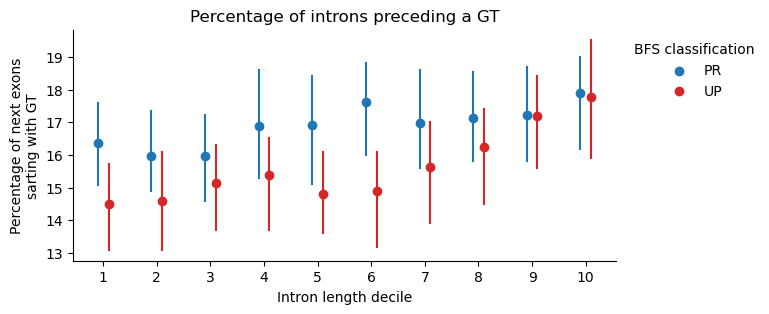

In [318]:
fig, ax = plt.subplots(figsize = (7, 3))
ax.scatter(np.arange(1, 11)-0.1, [100*x[0] for x in PR_GT_by_decile], c = 'tab:blue', label='PR')
for i, x in enumerate(PR_GT_by_decile):
    ax.plot([i+0.9, i+0.9], 100*np.array([np.quantile(x[1], 0.1), np.quantile(x[1], 0.9)]), c = 'tab:blue')

ax.scatter(np.arange(1, 11) + 0.1, [100*x[0] for x in UP_GT_by_decile], c = 'tab:red', label='UP')
for i, x in enumerate(UP_GT_by_decile):
    ax.plot([i+1.1, i+1.1], 100*np.array([np.quantile(x[1], 0.1), np.quantile(x[1], 0.9)]), c = 'tab:red')

ax.set_xticks(range(1, 11))
ax.set_xlabel('Intron length decile')
ax.set_ylabel('Percentage of next exons\nsarting with GT')

ax.spines[['top', 'right']].set_visible(False)

ax.legend(bbox_to_anchor=(1.01, 1), frameon=False, title='BFS classification', )

ax.set_title('Percentage of introns preceding a GT')
# plt.plot([x[0] for x in PR_GT_by_decile])
# plt.plot([x[0] for x in UP_GT_by_decile])

plt.savefig('revision_plots/Percentage_GT_next_exon.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/Percentage_GT_next_exon.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/Percentage_GT_next_exon.svg', dpi=300, bbox_inches='tight')    

In [265]:
super_long = [(5e4, 1e5), (1e5, 2e5), (2e5, 3e5), (3e5, 4e5), (4e5, 5e5), (5e5, 1e100)]

PR_GT_by_sl = []
UP_GT_by_sl = []
UP_len_list = []
PR_len_list = []
for sl in super_long:
    
    PR_GT_mean = (valid_juncs.loc[
        (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (valid_juncs.Coding)
        ].diplet_next_exon == 'GT').mean()

    PR_len_list.append(valid_juncs.loc[
        (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (valid_juncs.Coding)
        ].shape[0])
    
    UP_GT_mean = (valid_juncs.loc[
        (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (~valid_juncs.Coding)
        ].diplet_next_exon == 'GT').mean()

    UP_len_list.append(valid_juncs.loc[
        (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (~valid_juncs.Coding)
        ].shape[0])

    PR_GT_bootstrap = []
    UP_GT_bootstrap = []
    for i in tqdm(range(100)):
        idx = np.random.choice(valid_juncs.loc[
            (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (valid_juncs.Coding)
            ].index, 50, replace = True)
        PR_GT_bootstrap.append((valid_juncs.loc[idx].diplet_next_exon == 'GT').mean())

        idx = np.random.choice(valid_juncs.loc[
            (valid_juncs.intron_len >= sl[0]) & (valid_juncs.intron_len < sl[1]) & (~valid_juncs.Coding)
            ].index, 50, replace = True)
        UP_GT_bootstrap.append((valid_juncs.loc[idx].diplet_next_exon == 'GT').mean())

    PR_GT_by_sl.append([PR_GT_mean, PR_GT_bootstrap])
    UP_GT_by_sl.append([UP_GT_mean, UP_GT_bootstrap])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 270.25it/s]


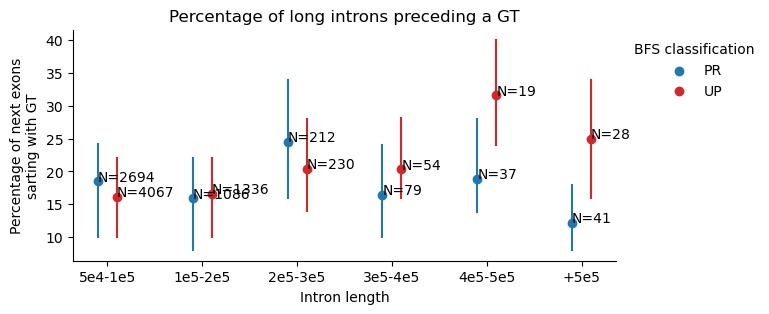

In [319]:
fig, ax = plt.subplots(figsize = (7, 3))
ax.scatter(np.arange(1, 7)-0.1, [100*x[0] for x in PR_GT_by_sl], c = 'tab:blue', label='PR')
for i, x in enumerate(PR_GT_by_sl):
    ax.plot([i+0.9, i+0.9], 100*np.array([np.quantile(x[1], 0.1), np.quantile(x[1], 0.9)]), c = 'tab:blue')
    ax.text(i+0.9, 100*x[0], 'N='+str(PR_len_list[i]))

ax.scatter(np.arange(1, 7) + 0.1, [100*x[0] for x in UP_GT_by_sl], c = 'tab:red', label='UP')
for i, x in enumerate(UP_GT_by_sl):
    ax.plot([i+1.1, i+1.1], 100*np.array([np.quantile(x[1], 0.1), np.quantile(x[1], 0.9)]), c = 'tab:red')

    ax.text(i+1.1, 100*x[0], 'N='+str(UP_len_list[i]))

ax.set_xticks(range(1, 7), ['5e4-1e5', '1e5-2e5', '2e5-3e5', '3e5-4e5', '4e5-5e5', '+5e5'])
ax.set_xlabel('Intron length')
ax.set_ylabel('Percentage of next exons\nsarting with GT')

ax.spines[['top', 'right']].set_visible(False)

ax.legend(bbox_to_anchor=(1.01, 1), frameon=False, title='BFS classification', )

ax.set_title('Percentage of long introns preceding a GT')

plt.savefig('revision_plots/Percentage_GT_next_exon_long_introns.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/Percentage_GT_next_exon_long_introns.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/Percentage_GT_next_exon_long_introns.svg', dpi=300, bbox_inches='tight')    

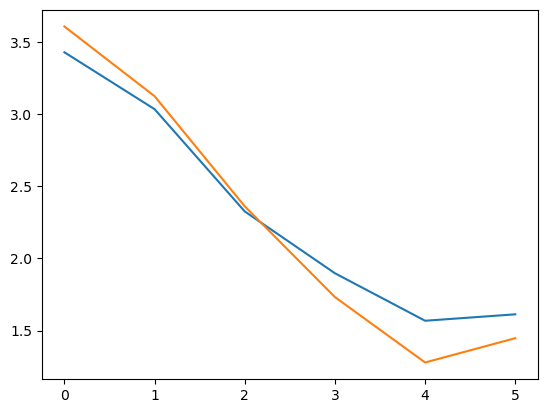

In [300]:
plt.plot([np.log10(x) for x in PR_len_list])
plt.plot([np.log10(x) for x in UP_len_list])

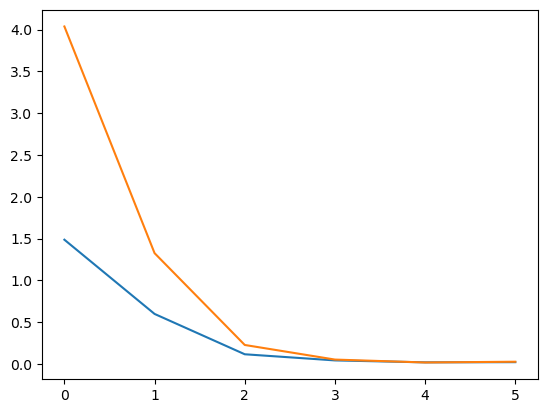

In [271]:
plt.plot([100*x/valid_juncs.loc[valid_juncs.Coding].shape[0] for x in PR_len_list])
plt.plot([100*x/valid_juncs.loc[~valid_juncs.Coding].shape[0] for x in UP_len_list])

In [182]:
(brain_class.loc[(~brain_class.Coding) & (brain_class.intron_len >= 50)].diplet_next_exon == 'GT').mean()

np.float64(0.15849760784547276)

In [ ]:
len_categories = 

In [175]:
brain_class.loc[(~brain_class.Coding) & (brain_class.intron_len >= 200)].intron_len.min()

np.int64(200)

In [102]:
get_diplets_full(fa, 'chr1', 930336, 931038, '+')

('GT', 'AG', 'AG')

In [100]:
fa = pyfastx.Fasta(genome)

get_diplets(fa, chrom,930336, 935771, '+')

('CC', 'AG', 'CC')

In [79]:
fa = pyfastx.Fasta(genome)

get_diplets(fa, chrom, start, end, strand)

('GT', 'TT', 'TG')

In [108]:
for idx, row in brain_class.loc[brain_class.Strand == '+'].head(50).iterrows():
    chrom, coords = row.Intron_coord.split(':')
    start, end = coords.split('-')
    start = int(start)
    end = int(end)
    strand = row.Strand

    print(get_diplets_full(fa, chrom, start, end, strand))

('GT', 'AG', 'GG')
('GT', 'AG', 'GG')
('GT', 'AG', 'GG')
('GT', 'AG', 'AA')
('GT', 'AG', 'AG')
('GT', 'AG', 'CC')
('GT', 'AG', 'CC')
('GT', 'AG', 'GT')
('GT', 'AG', 'CA')
('GT', 'AG', 'AG')
('GT', 'AG', 'AT')
('GT', 'AG', 'AT')
('GT', 'AG', 'GC')
('GT', 'AG', 'AT')
('GT', 'AG', 'AT')
('GT', 'AG', 'GG')
('GT', 'AG', 'GC')
('GT', 'AG', 'GC')
('GT', 'AG', 'GC')
('GT', 'AG', 'GT')
('GT', 'AG', 'GT')
('GT', 'AG', 'CC')
('GT', 'AG', 'CC')
('GC', 'AG', 'AT')
('GT', 'AG', 'AC')
('GT', 'AG', 'GT')
('GT', 'AG', 'CT')
('GT', 'AG', 'GG')
('GT', 'AG', 'GC')
('GT', 'AG', 'CT')
('GT', 'AG', 'TG')
('GT', 'AG', 'AT')
('GT', 'AG', 'GT')
('GT', 'AG', 'GT')
('GT', 'AG', 'GA')
('GT', 'AG', 'GA')
('GT', 'AG', 'GA')
('GT', 'AG', 'GG')
('GT', 'AG', 'GG')
('GT', 'AG', 'GT')
('GT', 'AG', 'AT')
('GT', 'AG', 'AT')
('GT', 'AG', 'CG')
('GT', 'AG', 'GC')
('GT', 'AG', 'AC')
('GT', 'AG', 'AC')
('GT', 'AG', 'AC')
('GT', 'AG', 'AC')
('GT', 'AG', 'AG')
('GT', 'AG', 'CC')


In [ ]:
chr1:959081-959214

In [47]:
Seq(fa.fetch('chr1', (959213,959214))).reverse_complement()

Seq('GT')

In [69]:
Seq(fa.fetch('chr1', (959081-1,959081+2))).reverse_complement()

Seq('AGGC')

In [ ]:
chr1:957273-958928

In [49]:
Seq(fa.fetch('chr1', (958927,958928))).reverse_complement()

Seq('GT')

In [50]:
Seq(fa.fetch('chr1', (957274,957275))).reverse_complement()

Seq('AG')

In [70]:
Seq(fa.fetch('chr1', (957273-1,957273+2))).reverse_complement()

Seq('AGCC')

In [ ]:
chr1:925189-925921

chr1:924948-925921

In [58]:
Seq(fa.fetch('chr1', (924949,924950)))

Seq('GT')

In [26]:

Seq(fa.fetch('chr1', (925190,925191)))

Seq('GT')

In [28]:
Seq(fa.fetch('chr1', (925920,925921)))

Seq('AG')

In [29]:
Seq(fa.fetch('chr1', (925922,925923)))

Seq('GG')

In [30]:
Seq(fa.fetch('chr1', (925920,925923)))

Seq('AGGG')

In [320]:
72.78+12.81+8.95+24.82+10.95+8.96+16.29

155.56